In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
import pandas as pd

traffic = pd.read_csv("traffic-count-vehicle-classification-2014-2017.csv")
pedestrian = pd.read_csv("pedestrian-historical-data.csv")

traffic.head()
pedestrian.head()


,datetime,region,durFrom10To20M,durFrom1To5M,durFrom20To40M,durFrom2To3H,durFrom3To4H,durFrom40To60M,durFrom4To6H,durFrom5To10M,durFrom60To90M,durFrom90To120M,durOver6H,durTotal,durUnder1M,filterId,numReturningVisitors,numVisitors,device_id,Lat Long
0,2021-07-01T01:00:00+10:00,2,14,11,14,0,0,7,0,7,13,58,0,230781,2,0.0,123,126,MobileCounting1,"-37.8025805, 144.9656012"
1,2021-07-01T04:00:00+10:00,3,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,0,0,MobileCounting1,"-37.8025805, 144.9656012"
2,2021-07-01T04:00:00+10:00,3,11,7,7,5,7,11,69,5,7,2,0,628972,2,0.0,133,133,MobileCounting1,"-37.8025805, 144.9656012"
3,2021-07-01T09:00:00+10:00,1,14,46,28,14,9,9,9,18,18,5,51,502304,69,0.0,244,290,MobileCounting1,"-37.8025805, 144.9656012"
4,2021-07-01T10:00:00+10:00,3,36,84,53,13,9,35,9,40,22,9,84,892097,71,0.0,398,465,MobileCounting1,"-37.8025805, 144.9656012"


In [5]:
print("Traffic dataset shape:", traffic.shape)
print("Pedestrian dataset shape:", pedestrian.shape)

print("\nTraffic columns:")
print(traffic.columns.tolist())

print("\nPedestrian columns:")
print(pedestrian.columns.tolist())

Traffic dataset shape: (60168, 28)
Pedestrian dataset shape: (18392, 20)

Traffic columns:
['date', 'road_name', 'location', 'suburb', 'speed_limit', 'direction', 'time', 'vehicle_class_1', 'vehicle_class_2', 'vehicle_class_3', 'vehicle_class_4', 'vehicle_class_5', 'vehicle_class_6', 'vehicle_class_7', 'vehicle_class_8', 'vehicle_class_9', 'vehicle_class_10', 'vehicle_class_11', 'vehicle_class_12', 'vehicle_class_13', 'motorcycle', 'bike', 'average_speed', '85th_percentile_speed', 'maximum_speed', 'road_segment', 'road_segment_1', 'road_segment_2']

Pedestrian columns:
['datetime', 'region', 'durFrom10To20M', 'durFrom1To5M', 'durFrom20To40M', 'durFrom2To3H', 'durFrom3To4H', 'durFrom40To60M', 'durFrom4To6H', 'durFrom5To10M', 'durFrom60To90M', 'durFrom90To120M', 'durOver6H', 'durTotal', 'durUnder1M', 'filterId', 'numReturningVisitors', 'numVisitors', 'device_id', 'Lat Long']


In [6]:
vehicle_cols = [f"vehicle_class_{i}" for i in range(1, 14)]

traffic['total_vehicles'] = traffic[vehicle_cols].sum(axis=1, skipna=True)

print(traffic[['road_name', 'suburb', 'time', 'total_vehicles']].head())

        road_name      suburb   time  total_vehicles
0  Collett Street  Kensington   3:00             0.0
1  Collett Street  Kensington  20:00             7.0
2  Collett Street  Kensington   1:00             0.0
3  Collett Street  Kensington  11:00             6.0
4  Collett Street  Kensington   6:00             3.0


In [7]:
traffic['date'] = pd.to_datetime(traffic['date'], errors='coerce')
traffic['hour'] = pd.to_datetime(traffic['time'], format='%H:%M', errors='coerce').dt.hour

traffic[['date', 'time', 'hour']].head()

,date,time,hour
0,2014-10-11,3:00,3
1,2014-10-11,20:00,20
2,2014-11-11,1:00,1
3,2014-11-11,11:00,11
4,2014-12-11,6:00,6


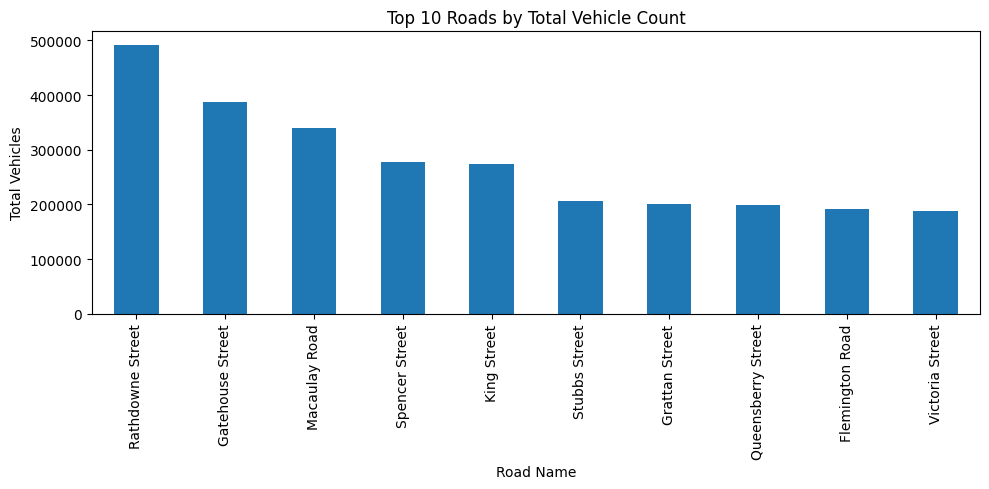

In [9]:
import os
import matplotlib.pyplot as plt

os.makedirs("outputs", exist_ok=True)

top_roads = traffic.groupby('road_name')['total_vehicles'].sum()\
                   .sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_roads.plot(kind='bar')
plt.title("Top 10 Roads by Total Vehicle Count")
plt.xlabel("Road Name")
plt.ylabel("Total Vehicles")
plt.tight_layout()

plt.savefig("outputs/top_traffic_roads.png")
plt.show()

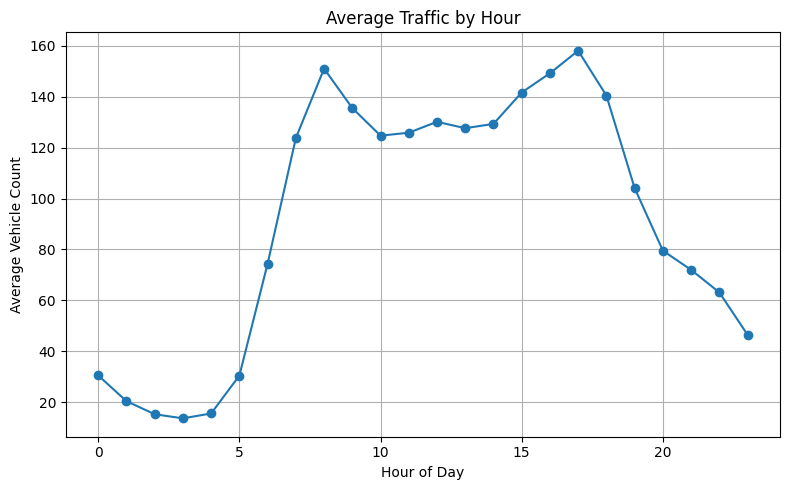

In [10]:
hourly_traffic = traffic.groupby('hour')['total_vehicles'].mean()

plt.figure(figsize=(8,5))
hourly_traffic.plot(marker='o')
plt.title("Average Traffic by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Vehicle Count")
plt.grid(True)
plt.tight_layout()
plt.show()

In [12]:
pedestrian['datetime'] = pd.to_datetime(
    pedestrian['datetime'],
    errors='coerce',
    utc=True
).dt.tz_convert('Australia/Melbourne')

pedestrian['hour'] = pedestrian['datetime'].dt.hour

In [13]:
print("Total pedestrian records:", len(pedestrian))
print("Unique devices:", pedestrian['device_id'].nunique())
print("Total visitors:", pedestrian['numVisitors'].sum())

Total pedestrian records: 18392
Unique devices: 1
Total visitors: 3419766


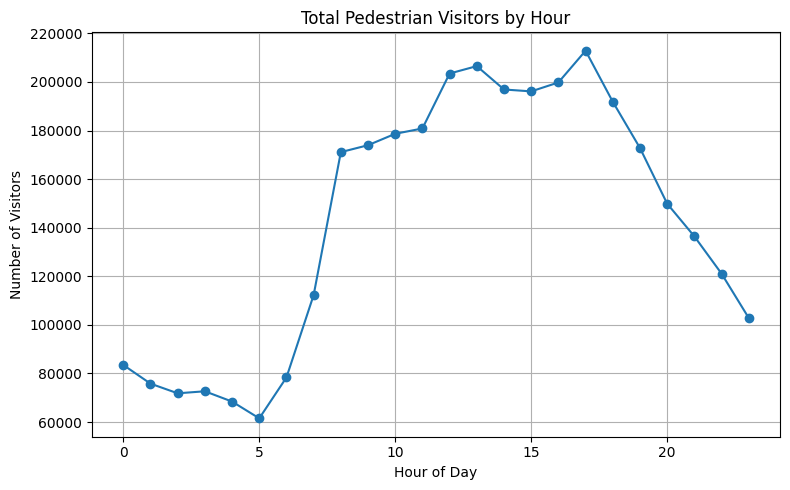

In [14]:
hourly_ped = pedestrian.groupby('hour')['numVisitors'].sum()

plt.figure(figsize=(8,5))
hourly_ped.plot(marker='o')
plt.title("Total Pedestrian Visitors by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Visitors")
plt.grid(True)
plt.tight_layout()
plt.savefig("outputs/pedestrian_hourly_counts.png")
plt.show()

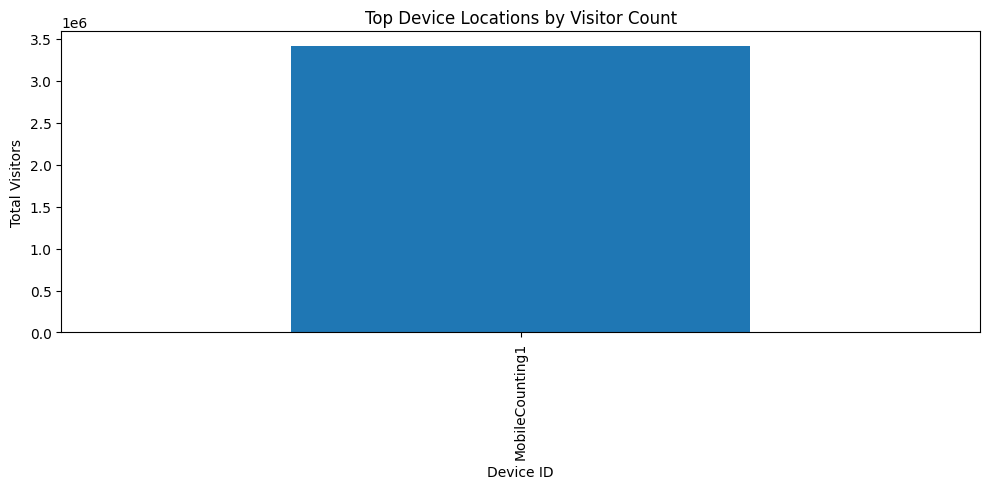

In [15]:
top_devices = pedestrian.groupby('device_id')['numVisitors'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_devices.plot(kind='bar')
plt.title("Top Device Locations by Visitor Count")
plt.xlabel("Device ID")
plt.ylabel("Total Visitors")
plt.tight_layout()
plt.show()